In [3]:
import os 
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, HTML

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

In [9]:
train_data = pd.read_csv("datasets/train.csv")
test_data = pd.read_csv("datasets/test.csv")

train_data.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [44]:
train_data.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [ ]:
missing_values = train_data.isna().sum()
print(missing_values)



id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64


In [15]:

duplicate_rows = train_data.duplicated().sum()
print(duplicate_rows)

0


Target distribution:


,count,percentage
addicted_label,,
0,200895,29.06
1,490474,70.94


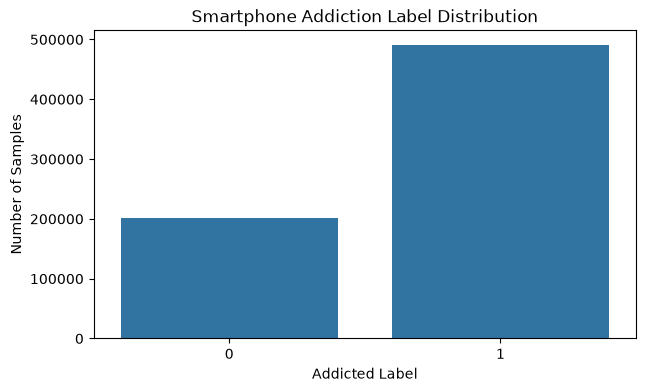

Positive-class rate: 0.7094
Positive-class percentage: 70.94%


In [28]:
TARGET = "addicted_label"

if TARGET in train_data.columns:

    target_counts = train_data[TARGET].value_counts(
        dropna=False
    ).sort_index()

    target_percentages = (
        train_data[TARGET]
        .value_counts(normalize=True, dropna=False)
        .sort_index()
        * 100
    )

    target_summary = pd.DataFrame({
        "count": target_counts,
        "percentage": target_percentages.round(2)
    })

    print("Target distribution:")
    display(target_summary)

    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=train_data,
        x=TARGET
    )

    plt.title("Smartphone Addiction Label Distribution")
    plt.xlabel("Addicted Label")
    plt.ylabel("Number of Samples")

    plt.show()

    positive_rate = train_data[TARGET].mean()

    print(f"Positive-class rate: {positive_rate:.4f}")
    print(f"Positive-class percentage: {positive_rate * 100:.2f}%")


In [31]:
train_features = set(train_data.columns) - {TARGET}
test_features = set(test_data.columns)
only_in_train = sorted(train_features - test_features)
only_in_test = sorted(test_features - train_features)
common_features = sorted(train_features & test_features)

print(f"Common features: {len(common_features)}")
print(f"Only in train: {len(only_in_train)}")
print(f"Only in test: {len(only_in_test)}")

Common features: 13
Only in train: 0
Only in test: 0


In [32]:
possible_id_columns = [
    col for col in train_data.columns
    if "id" in col.lower()
]

print("Possible ID columns:", possible_id_columns)

for id_col in possible_id_columns:


    print(f"ID ANALYSIS: {id_col}")

    print("Train unique IDs:", train_data[id_col].nunique())
    print("Train duplicate IDs:", train_data[id_col].duplicated().sum())

    if id_col in test_data.columns:
        print("Test unique IDs:", test_data[id_col].nunique())
        print("Test duplicate IDs:", test_data[id_col].duplicated().sum())

        overlap = set(train_data[id_col]).intersection(
            set(test_data[id_col])
        )

        print("Train/test ID overlap:", len(overlap))

    print("\nFirst 10 IDs:")
    print(train_data[id_col].head(10).tolist())

    if pd.api.types.is_numeric_dtype(train_data[id_col]):

        print("\nID summary:")
        display(
            train_data[id_col]
            .describe()
            .to_frame("value")
        )

        sorted_ids = np.sort(
            train_data[id_col]
            .dropna()
            .unique()
        )

        if len(sorted_ids) > 1:
            differences = np.diff(sorted_ids)

            print(
                "Most common ID differences:",
                pd.Series(differences)
                .value_counts()
                .head(10)
                .to_dict()
            )

Possible ID columns: ['id']
ID ANALYSIS: id
Train unique IDs: 691369
Train duplicate IDs: 0
Test unique IDs: 296302
Test duplicate IDs: 0
Train/test ID overlap: 0

First 10 IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

ID summary:


,value
count,691369.000000
mean,345684.000000
std,199581.183467
min,0.000000
25%,172842.000000
50%,345684.000000
75%,518526.000000
max,691368.000000


Most common ID differences: {1: 691368}


In [34]:
from sklearn.metrics import roc_auc_score

for id_col in possible_id_columns:

    if (
        pd.api.types.is_numeric_dtype(train_data[id_col])
        and train_data[id_col].nunique() > 1
    ):

        valid = train_data[
            [id_col, TARGET]
        ].dropna()

        if valid[TARGET].nunique() == 2:

            id_auc = roc_auc_score(
                valid[TARGET],
                valid[id_col]
            )

            id_auc = max(
                id_auc,
                1 - id_auc
            )

            print(
                f"{id_col} standalone AUC: "
                f"{id_auc:.5f}"
            )

            if id_auc > 0.60:
                print(
                    "The ID appears associated with the target. "
                    "This may indicate ordering, grouping, or leakage. "
                    "We will validate it carefully."
                )
            else:
                print(
                    "The ID does not show a strong direct association "
                    "with the target."
                )

id standalone AUC: 0.50070
The ID does not show a strong direct association with the target.


In [36]:
feature_columns = [
    col for col in train_data.columns
    if col != TARGET
]

numeric_columns = train_data[
    feature_columns
].select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = [
    col for col in feature_columns
    if col not in numeric_columns
]

print(f"Total features: {len(feature_columns)}")
print(f"Numeric features: {len(numeric_columns)}")
print(f"Categorical/text features: {len(categorical_columns)}")

print("\nNumeric columns:")
print(numeric_columns)

print("\nCategorical/text columns:")
print(categorical_columns)

Total features: 13
Numeric features: 10
Categorical/text features: 3

Numeric columns:
['id', 'age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']

Categorical/text columns:
['gender', 'stress_level', 'academic_work_impact']


In [38]:
if numeric_columns:

    numeric_summary = train_data[
        numeric_columns
    ].describe().T

    numeric_summary["missing_percent"] = (
        train_data[numeric_columns]
        .isna()
        .mean()
        * 100
    ).round(2)

    numeric_summary["unique_values"] = (
        train_data[numeric_columns]
        .nunique()
    )

    display(
        numeric_summary.sort_values(
            "missing_percent",
            ascending=False
        )
    )

,count,mean,std,min,25%,50%,75%,max,missing_percent,unique_values
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00,19.38,721
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00,18.34,401
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56,16.21,1437
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00,13.86,1389
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00,11.67,166
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00,9.78,231
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00,7.45,600
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00,6.43,451
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00,4.18,18
id,691369.0,345684.000000,199581.183467,0.00,172842.00,345684.00,518526.00,691368.00,0.00,691369


In [40]:
if categorical_columns:

    categorical_summary = pd.DataFrame({
        "dtype": train_data[categorical_columns].dtypes.astype(str),
        "unique_values": train_data[categorical_columns].nunique(),
        "missing_percent": (
            train_data[categorical_columns]
            .isna()
            .mean()
            * 100
        ).round(2)
    })

    display(
        categorical_summary.sort_values(
            "unique_values",
            ascending=False
        )
    )

,dtype,unique_values,missing_percent
gender,object,3,4.20
stress_level,object,3,7.98
academic_work_impact,object,2,6.40


In [42]:
from scipy.stats import ks_2samp

distribution_results = []

for col in numeric_columns:

    if col in test_data.columns:

        train_values = (
            train_data[col]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        test_values = (
            test_data[col]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(train_values) > 10 and len(test_values) > 10:

            statistic, p_value = ks_2samp(
                train_values,
                test_values
            )

            distribution_results.append({
                "feature": col,
                "ks_statistic": statistic,
                "p_value": p_value,
                "train_mean": train_values.mean(),
                "test_mean": test_values.mean(),
                "train_missing_%": (
                    train_data[col].isna().mean() * 100
                ),
                "test_missing_%": (
                    test_data[col].isna().mean() * 100
                )
            })

shift_df = pd.DataFrame(
    distribution_results
)

if not shift_df.empty:

    shift_df = shift_df.sort_values(
        "ks_statistic",
        ascending=False
    )

    print(
        "Features with the largest train/test "
        "distribution differences:"
    )

    display(
        shift_df.head(20)
    )

Features with the largest train/test distribution differences:


,feature,ks_statistic,p_value,train_mean,test_mean,train_missing_%,test_missing_%
0,id,1.000000,0.000000,345684.000000,839519.500000,0.000000,0.000000
7,notifications_per_day,0.002683,0.140034,145.894900,145.748066,9.775388,11.549365
6,sleep_hours,0.002180,0.319206,6.804334,6.801704,6.433612,7.578417
4,gaming_hours,0.002089,0.459751,1.459265,1.457668,18.343461,20.053864
8,app_opens_per_day,0.002083,0.389429,102.636781,102.656216,11.673940,8.675271
2,daily_screen_time_hours,0.001727,0.646735,7.640865,7.640771,13.864376,11.065737
9,weekend_screen_time,0.001671,0.720232,9.479866,9.474575,16.208855,17.109908
3,social_media_hours,0.001599,0.770263,2.471038,2.471224,19.381112,15.996180
1,age,0.001448,0.804106,26.615408,26.608689,4.184307,5.783964
5,work_study_hours,0.000915,0.997345,2.366971,2.365962,7.451592,9.374557


In [46]:
categorical_columns = [
    "gender",
    "stress_level",
    "academic_work_impact"
]

for col in categorical_columns:

    print(f"COLUMN: {col}")

    print(
        "Unique values:",
        train_data[col].nunique(
            dropna=False
        )
    )

    print("\nTrain value counts:")
    display(
        train_data[col]
        .value_counts(
            dropna=False
        )
    )

    print("\nTest value counts:")
    display(
        test_data[col]
        .value_counts(
            dropna=False
        )
    )

COLUMN: gender
Unique values: 4

Train value counts:


gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64


Test value counts:


gender
Male      95357
Female    94295
Other     92438
NaN       14212
Name: count, dtype: int64

COLUMN: stress_level
Unique values: 4

Train value counts:


...

stress_level
High      95622
Low       90746
Medium    90308
NaN       19626
Name: count, dtype: int64

COLUMN: academic_work_impact
Unique values: 3

Train value counts:


academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64


Test value counts:


academic_work_impact
Yes    138694
No     131887
NaN     25721
Name: count, dtype: int64

In [48]:
numeric_columns = [
    "age",
    "daily_screen_time_hours",
    "social_media_hours",
    "gaming_hours",
    "work_study_hours",
    "sleep_hours",
    "notifications_per_day",
    "app_opens_per_day",
    "weekend_screen_time"
]

numeric_summary = train_data[
    numeric_columns
].describe().T

numeric_summary[
    "missing_percentage"
] = (
    train_data[
        numeric_columns
    ]
    .isna()
    .mean()
    * 100
).round(2)

numeric_summary[
    "unique_values"
] = (
    train_data[
        numeric_columns
    ]
    .nunique()
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing_percentage,unique_values
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00,4.18,18
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00,13.86,1389
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00,19.38,721
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00,18.34,401
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00,7.45,600
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00,6.43,451
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00,9.78,231
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00,11.67,166
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56,16.21,1437
